# 02 Feature Engineering: RFM Analysis

In this stage, we transition from raw transactional data to customer-centric metrics. We will calculate the RFM (Recency, Frequency, Monetary) scores, which are the industry standard for behavioral segmentation in digital marketing. This allows us to quantify customer value and identify patterns for our predictive model.

In [4]:
import pandas as pd

# Load Master Dataset (already merged)
df = pd.read_csv('../Data/Processed/master_cleaned.csv', parse_dates=['order_purchase_timestamp'])

# 1. Define snapshot date
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Calculate RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

# 3. Rename columns for clarity
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

In [3]:
print(display(rfm.head()))

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


None


In [5]:
print(rfm.describe())

            Recency     Frequency      Monetary
count  96096.000000  96096.000000  96096.000000
mean     288.735691      1.034809    166.592492
std      153.414676      0.214384    231.428332
min        1.000000      1.000000      0.000000
25%      164.000000      1.000000     63.120000
50%      269.000000      1.000000    108.000000
75%      398.000000      1.000000    183.530000
max      773.000000     17.000000  13664.080000


**Descriptive analysis reveals a critical loyalty challenge:** more than 75% of customers have interacted with the platform only once. This makes churn prediction a task of identifying early warning signs, since we lack a history of repeat engagement for most of the customer base. The value of the model will lie in predicting who has the potential to become a repeat customer versus those who are purely transactional.

In [ ]:
# Visualization Setup

import seaborn as sns
import matplotlib.pyplot as plt

# Palette "Coffee & Tech"
coffee_palette = ["#3D2B1F", "#6F4E37", "#A67B5B", "#ECB176", "#2D4356"]

# Global Configurations
sns.set_theme(style="white")
sns.set_palette(sns.color_palette(coffee_palette))

# Details
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'bold'

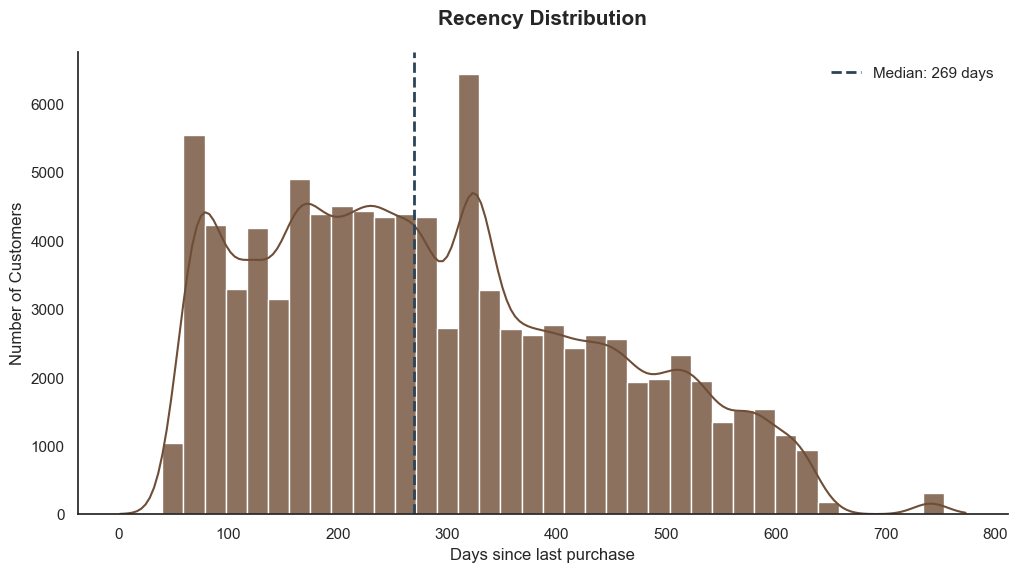

In [10]:
plt.figure(figsize=(12, 6))

# Histogram with KDE (Kernel Density Estimate)
ax = sns.histplot(rfm['Recency'], bins=40, kde=True, color="#6F4E37", alpha=0.8)

# Line of the Median (Snapshot of the health of the base)
median_val = rfm['Recency'].median()
plt.axvline(median_val, color='#2D4356', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} days')

# Titles and labels with business intent
plt.title('Recency Distribution', fontsize=15, pad=20)
plt.xlabel('Days since last purchase', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.legend(frameon=False)
sns.despine() # Clean up the plot by removing top and right spines
plt.show()

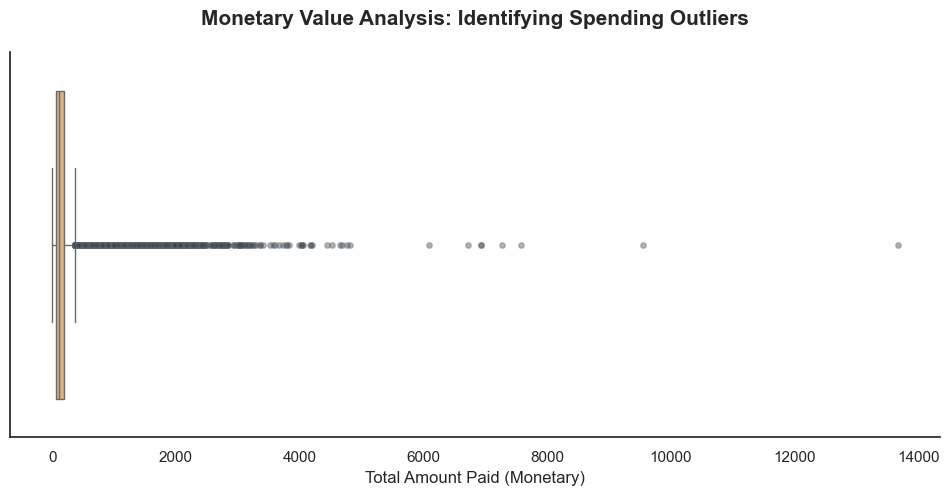

In [12]:
plt.figure(figsize=(12, 5))

# Horizontal Boxplot for Monetary Value
sns.boxplot(x=rfm['Monetary'], color="#ECB176", flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "#2D4356", "alpha": 0.4})

plt.title('Monetary Value Analysis: Identifying Spending Outliers', fontsize=15, pad=20)
plt.xlabel('Total Amount Paid (Monetary)', fontsize=12)
sns.despine()
plt.show()

Due to huge amount of outliers (real outliers since the context of the data is a marketplace) a logaritmic approach in order to visualize will be used

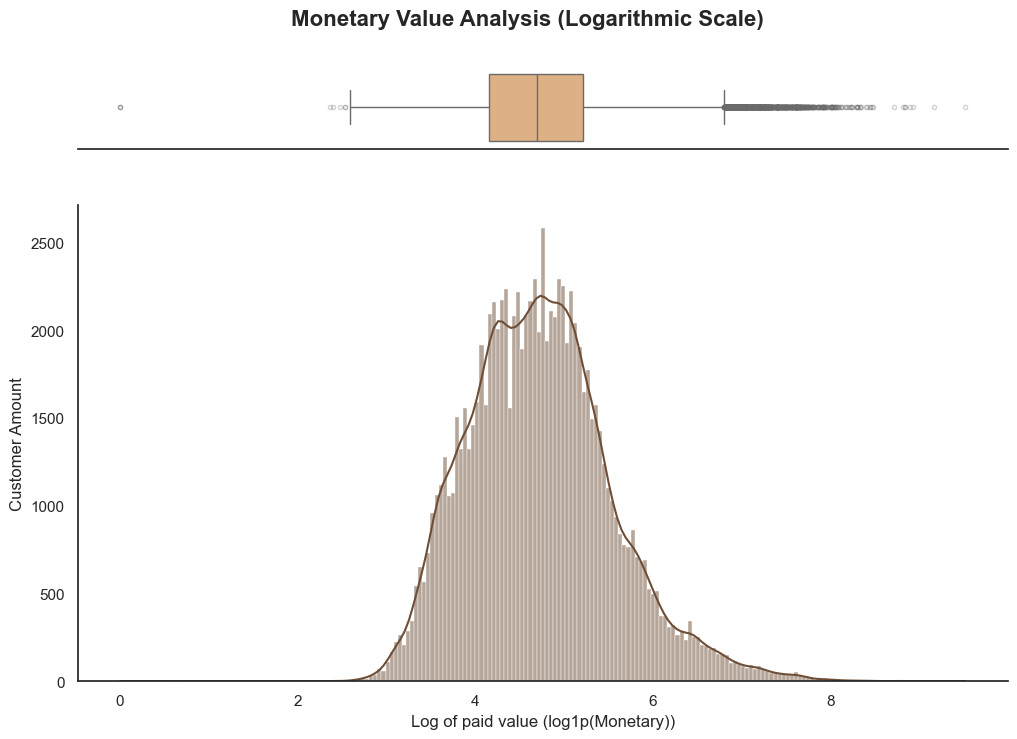

In [15]:
import numpy as np

# 1. Apply Log Transformation to Monetary Value
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# 2. Improved Visualization
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(12, 8), 
                                     gridspec_kw={"height_ratios": (.15, .85)})

# Upper Boxplot (Identidad "Coffee & Tech")
sns.boxplot(x=rfm['Monetary_log'], ax=ax_box, color="#ECB176", flierprops={"marker": "o", "markersize": 3, "alpha": 0.3})
ax_box.set(xlabel='') # Quitar etiqueta del eje X en el boxplot

# Histogram with KDE (Kernel Density Estimate)
sns.histplot(rfm['Monetary_log'], ax=ax_hist, kde=True, color="#6F4E37")

plt.suptitle('Monetary Value Analysis (Logarithmic Scale)', fontsize=16, fontweight='bold', y=0.95)
ax_hist.set_xlabel('Log of paid value (log1p(Monetary))', fontsize=12)
ax_hist.set_ylabel('Customer Amount', fontsize=12)

sns.despine(ax=ax_hist)
sns.despine(ax=ax_box, left=True)
plt.show()